## k-means

- 엘보우 기법을 통해 신뢰도가 좋은 군집을 판별
- 프리미엄과 가성비 브랜드를 비율로 따져서 데이터를 분석
- 현재는 군집 4개를 기준으로 함 (3-2번이 군집 갯수)
- 실루엣 점수를 통해 모델의 성능을 평가!!

✅ 데이터 로드 완료


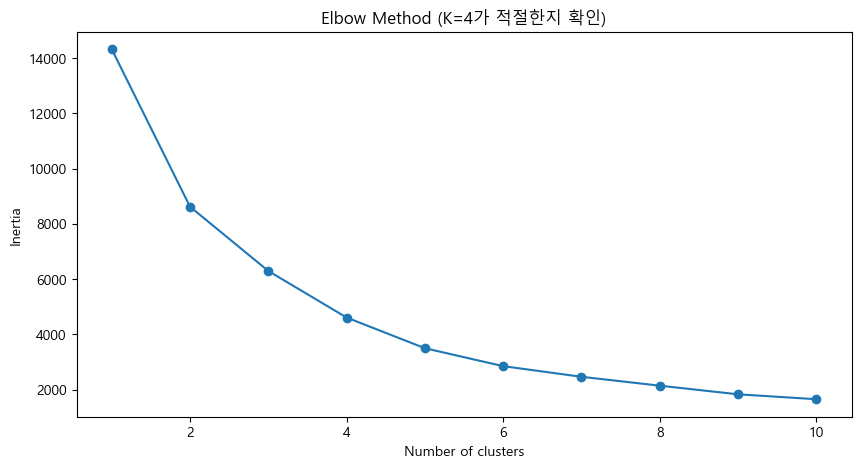

📊 실루엣 점수 (Silhouette Score): 0.3932

📍 군집별 평균 지표:


,총_승하차객수_log,브랜드_밀도,프리미엄_비율,가성비_비율,브랜드_다양성,총_승하차객수
클러스터,,,,,,
0,9.599189,10.822870,0.360583,0.639417,7.513453,18992.284753
1,8.733088,4.112760,0.083234,0.916766,3.376855,8368.534125
2,10.162950,26.040541,0.412027,0.587973,10.736486,42032.864865
3,7.502571,0.722581,0.253419,0.082065,0.664516,5280.529032


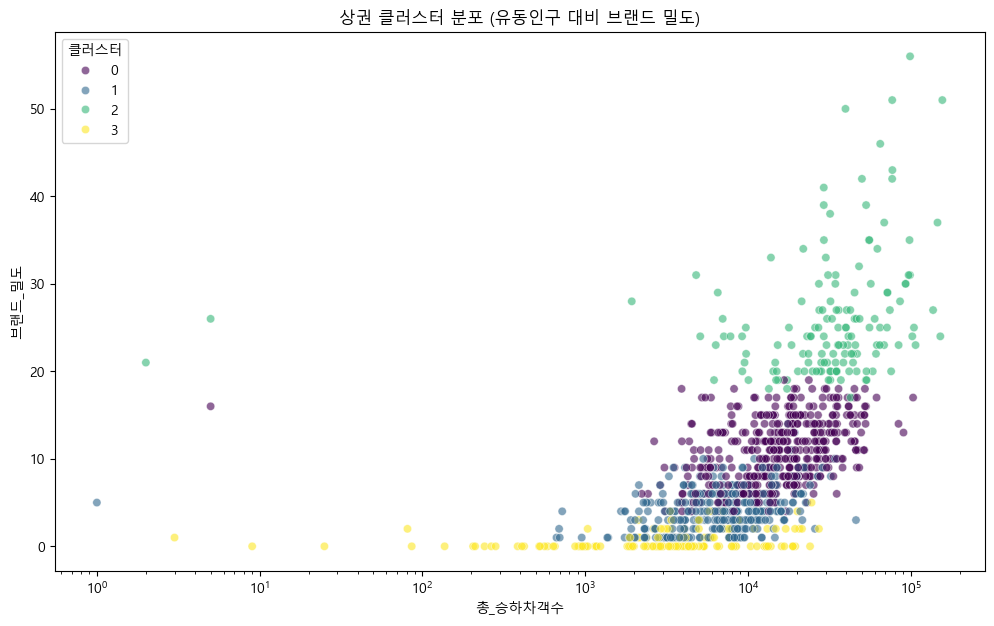

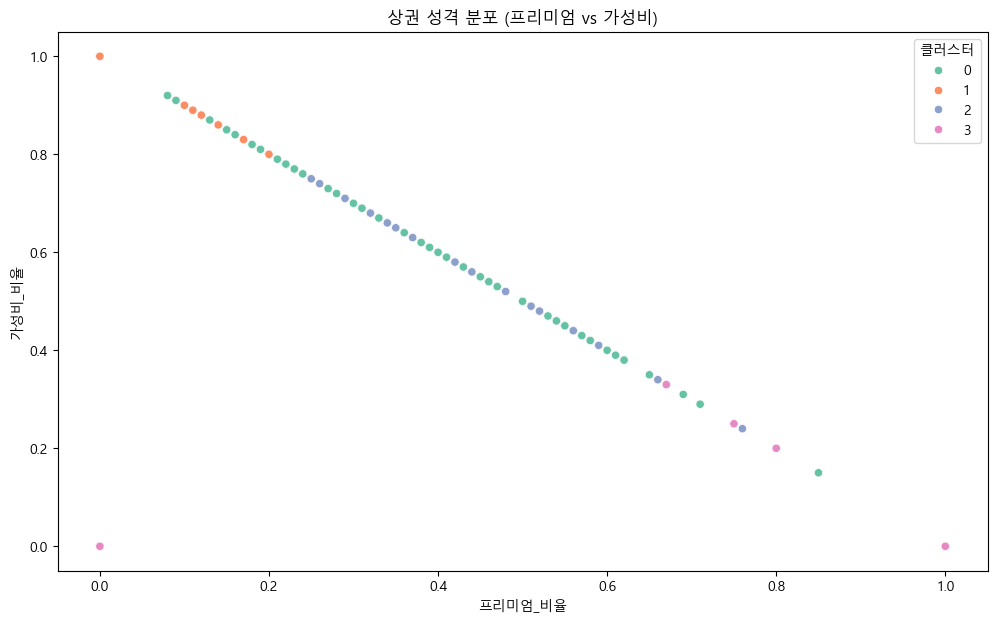

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from math import radians, cos, sin, asin, sqrt
import os

# 한글 폰트 설정 (Windows 기준, Mac은 'AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# --- [1. 데이터 로드] ---
# DB 연결 정보 (사용자 환경에 맞게 수정)
DB_HOST = "localhost"
DB_USER = "root"
DB_PASS = "1234"
DB_NAME = "coffee_store"
engine = create_engine(f'mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:3306/{DB_NAME}')

# 데이터 불러오기
try:
    COFFEE_STORES_DF = pd.read_sql("SELECT 브랜드명, 매장명, 주소, 경도, 위도 FROM coffee_chain", engine)
    station_df = pd.read_csv('전체_역사정보_최종_정제_v58.csv')
    print("✅ 데이터 로드 완료")
except Exception as e:
    print(f"❌ 에러 발생: {e}")

# --- [2. 유틸리티 함수 및 전처리] ---
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 6371 * 2 * asin(sqrt(a))

premium_brands = ['스타벅스', '투썸플레이스', '폴바셋', '할리스', '파스쿠찌', '공차', '디저트39']
budget_brands = ['메가커피', '빽다방', '컴포즈커피', '더벤티', '메머드커피', '이디야', '던킨도너츠', '하삼동커피']

def get_station_features(station_row, stores_df):
    s_lat, s_lon = station_row['위도'], station_row['경도']
    nearby = stores_df[
        (stores_df['위도'].between(s_lat - 0.01, s_lat + 0.01)) & 
        (stores_df['경도'].between(s_lon - 0.01, s_lon + 0.01))
    ].copy()
    if nearby.empty: return pd.Series([0, 0.0, 0.0, 0])
    nearby['dist'] = nearby.apply(lambda x: haversine(s_lon, s_lat, x['경도'], x['위도']), axis=1)
    in_500m = nearby[nearby['dist'] <= 0.5]
    total_count = len(in_500m)
    if total_count == 0: return pd.Series([0, 0.0, 0.0, 0])
    p_ratio = round(in_500m['브랜드명'].isin(premium_brands).sum() / total_count, 2)
    b_ratio = round(in_500m['브랜드명'].isin(budget_brands).sum() / total_count, 2)
    diversity = in_500m['브랜드명'].nunique()
    return pd.Series([total_count, p_ratio, b_ratio, diversity])

# 피처 생성
stations = station_df.dropna(subset=['위도', '경도']).copy()
stations['총_승하차객수'] = stations['1월 승차이용객수'] + stations['1월 하차이용객수']
features = stations.apply(lambda x: get_station_features(x, COFFEE_STORES_DF), axis=1)
features.columns = ['브랜드_밀도', '프리미엄_비율', '가성비_비율', '브랜드_다양성']
final_df = pd.concat([stations, features], axis=1)

# 전처리 (로그 변환 및 스케일링)
final_df['총_승하차객수_log'] = np.log1p(final_df['총_승하차객수'])
target_cols = ['총_승하차객수_log', '브랜드_밀도', '프리미엄_비율', '가성비_비율', '브랜드_다양성']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(final_df[target_cols].fillna(0))

# 가중치 적용 (app.py와 동일)
weights = np.array([1.0, 2.5, 1.5, 1.5, 1.2]) 
X_weighted = X_scaled * weights

# --- [3. 모델 성능 검증 (Accuracy 대신 활용)] ---

# 1. 엘보우 방법 (최적의 K 찾기)
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=30)
    km.fit(X_weighted)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method (K=4가 적절한지 확인)')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# 2. 실루엣 점수 (군집화의 밀집도/분리도)
# 1에 가까울수록 군집화가 잘 된 것임
kmeans = KMeans(n_clusters=4, random_state=42, n_init=30)
cluster_labels = kmeans.fit_predict(X_weighted)
sil_score = silhouette_score(X_weighted, cluster_labels)
print(f"📊 실루엣 점수 (Silhouette Score): {sil_score:.4f}")

# --- [4. 결과 분석 및 시각화] ---
final_df['클러스터'] = cluster_labels

# 군집별 특징 파악
cluster_analysis = final_df.groupby('클러스터')[target_cols + ['총_승하차객수']].mean()
print("\n📍 군집별 평균 지표:")
display(cluster_analysis)

# 시각화: 승하차객수 vs 브랜드 밀도
plt.figure(figsize=(12, 7))
sns.scatterplot(data=final_df, x='총_승하차객수', y='브랜드_밀도', hue='클러스터', palette='viridis', alpha=0.6)
plt.title('상권 클러스터 분포 (유동인구 대비 브랜드 밀도)')
plt.xscale('log') # 승하차객수 편차가 크므로 로그 스케일
plt.show()

# 시각화: 프리미엄 비율 vs 가성비 비율
plt.figure(figsize=(12, 7))
sns.scatterplot(data=final_df, x='프리미엄_비율', y='가성비_비율', hue='클러스터', palette='Set2')
plt.title('상권 성격 분포 (프리미엄 vs 가성비)')
plt.show()